In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

In [5]:
df=pd.read_csv("demand_forecasting.csv")
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S004,P0013,Groceries,West,136,104,385,20.24,10,Snowy,0,18.90,Winter,0,110
2,2022-01-01,S004,P0012,Electronics,West,111,111,113,118.15,0,Snowy,0,133.46,Winter,0,103
3,2022-01-01,S004,P0011,Clothing,West,195,60,293,52.89,0,Snowy,0,62.29,Winter,0,61
4,2022-01-01,S004,P0010,Groceries,West,223,120,597,30.02,0,Snowy,0,29.15,Winter,0,128


In [56]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='object')

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.weekday

In [61]:
features = [
    "Price",
    "Discount",
    "Inventory Level",
    "Promotion",
    "Competitor Pricing",
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality",
    "Epidemic",
    "Year",
    "Month",
    "Day",
    "Weekday"
]

features

['Price',
 'Discount',
 'Inventory Level',
 'Promotion',
 'Competitor Pricing',
 'Category',
 'Region',
 'Weather Condition',
 'Seasonality',
 'Epidemic',
 'Year',
 'Month',
 'Day',
 'Weekday']

In [62]:
target ="Demand"

In [63]:
X=df[features].copy()
X

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category,Region,Weather Condition,Seasonality,Epidemic,Year,Month,Day,Weekday
0,72.72,5,195,0,85.73,Electronics,North,Snowy,Winter,0,2022,1,1,5
1,20.24,10,136,0,18.90,Groceries,West,Snowy,Winter,0,2022,1,1,5
2,118.15,0,111,0,133.46,Electronics,West,Snowy,Winter,0,2022,1,1,5
3,52.89,0,195,0,62.29,Clothing,West,Snowy,Winter,0,2022,1,1,5
4,30.02,0,223,0,29.15,Groceries,West,Snowy,Winter,0,2022,1,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,26.98,0,85,0,24.65,Groceries,South,Snowy,Winter,0,2024,1,30,1
75996,26.84,10,414,0,29.55,Toys,South,Snowy,Winter,0,2024,1,30,1
75997,63.58,10,98,0,76.22,Clothing,South,Snowy,Winter,0,2024,1,30,1
75998,91.50,5,88,0,85.74,Clothing,South,Snowy,Winter,0,2024,1,30,1


In [64]:
y=df[target]
y

0        115
1        110
2        103
3         61
4        128
        ... 
75995     96
75996    109
75997    118
75998    105
75999     73
Name: Demand, Length: 76000, dtype: int64

In [65]:
categorical_cols = [
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality"
]

numeric_cols = [
    "Price",
    "Discount",
    "Inventory Level",
    "Promotion",
    "Competitor Pricing",
    "Epidemic",
    "Year",
    "Month",
    "Day",
    "Weekday"
]

print("Categorical features:", categorical_cols)
print("Numerical features:", numeric_cols)

Categorical features: ['Category', 'Region', 'Weather Condition', 'Seasonality']
Numerical features: ['Price', 'Discount', 'Inventory Level', 'Promotion', 'Competitor Pricing', 'Epidemic', 'Year', 'Month', 'Day', 'Weekday']


In [66]:
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("numerical", "passthrough", numeric_cols)
    ]
)

In [67]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (60800, 14)
Test set: (15200, 14)


In [68]:
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)


In [69]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", xgb)
    ]
)

In [ ]:
param_dict = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [3, 4, 6, 8],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5]
}
tscv = TimeSeriesSplit(n_splits=3)

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dict,
    n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

In [71]:
random_search.fit(X_train,y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('categorical',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['Category',
                                                                                'Region',
                                                                                'Weather '
                                                                                'Condition',
                                                                                'Seasonality']),
                                                                              ('numerical',
                                                                               'passthrough',
                                                                               ['Price',
                                                                                'Discount',
                                                                                'Inventory '
                                                                                'Level',
                                                                                'Promot...
                                                           num_parallel_tree=None,
                                                           random_state=42, ...))]),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.7, 0.8,
                                                                    1.0],
                                        'model__learning_rate': [0.01, 0.05,
                                                                 0.1],
                                        'model__max_depth': [3, 4, 6, 8],
                                        'model__min_child_weight': [1, 3, 5],
                                        'model__n_estimators': [200, 300, 500],
                                        'model__subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='neg_mean_absolute_error',
                   verbose=1)

In [72]:
random_search.best_params_

{'model__subsample': 0.8,
 'model__n_estimators': 300,
 'model__min_child_weight': 5,
 'model__max_depth': 8,
 'model__learning_rate': 0.05,
 'model__colsample_bytree': 0.8}

In [73]:
best_model=random_search.best_estimator_

In [74]:
y_pred=best_model.predict(X_test)

In [75]:
best_model.predict(X_test)

array([169.58287, 128.8323 ,  77.82993, ..., 101.93483, 113.6292 ,
        79.56706], dtype=float32)

In [28]:
mean_squared_error(y_test,y_pred,squared=False)

35.61235964272675

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE :", mae)

MAE : 19.76611033897651


In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE :", rmse)

RMSE : 26.844156483967705


In [ ]:
r2 = r2_score(y_test, y_pred)
print("R² :", r2)

R² : 0.6292444760801459


In [ ]:
comparison = pd.DataFrame({
    "Actual Demand": y_test.values,
    "Predicted Demand": y_pred
})
comparison.head(20)

,Actual Demand,Predicted Demand
0,182,169.582870
1,102,128.832306
2,150,77.829933
3,117,140.726013
4,134,166.210495
5,145,117.375626
6,89,96.252365
7,106,112.066071
8,102,138.512054
9,176,175.198456


In [ ]:
model = best_model.named_steps["model"]
preprocessor_fitted = best_model.named_steps["preprocessor"]
feature_names = preprocessor_fitted.get_feature_names_out()
feature_importance = pd.Series(
    model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)
feature_importance.head(20)

categorical__Category_Furniture          0.191314
numerical__Epidemic                      0.172256
numerical__Promotion                     0.156876
categorical__Category_Groceries          0.138503
categorical__Category_Clothing           0.048404
categorical__Seasonality_Summer          0.044213
categorical__Category_Toys               0.040428
categorical__Category_Electronics        0.028970
categorical__Weather Condition_Sunny     0.026124
numerical__Price                         0.015752
categorical__Weather Condition_Cloudy    0.012845
categorical__Region_South                0.011994
categorical__Weather Condition_Rainy     0.011949
categorical__Region_North                0.011857
categorical__Region_West                 0.011658
categorical__Region_East                 0.010246
categorical__Seasonality_Winter          0.009789
numerical__Discount                      0.008781
numerical__Competitor Pricing            0.008227
categorical__Weather Condition_Snowy     0.008006


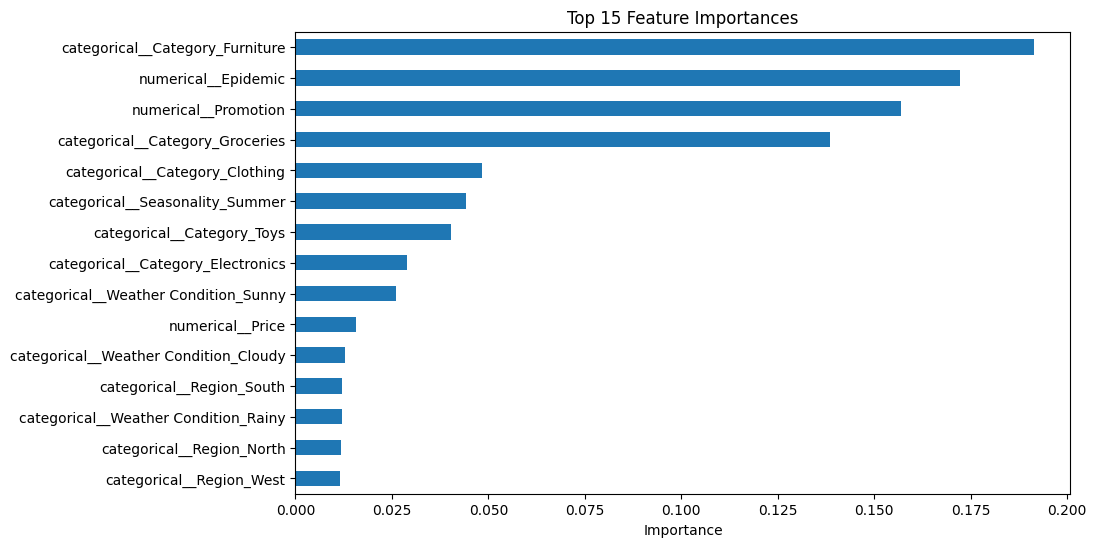

In [ ]:
feature_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.show()

<Axes: title={'center': 'Feature Importances'}>

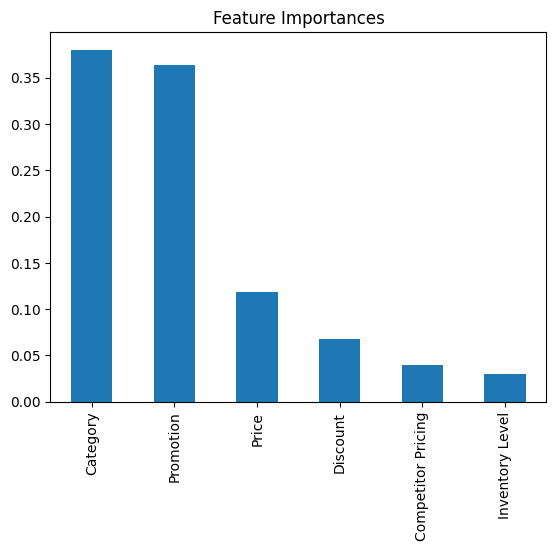

In [32]:
feature_importance.plot(kind="bar",title="Feature Importances")

In [81]:
with open("xgboost_demand_pipeline.pkl", "wb") as f:
    pickle.dump(best_model, f)

In [82]:
print("Model saved successfully.")
print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)

Model saved successfully.
MAE : 27.010080599220174
RMSE : 26.844156483967705
R² : 0.6292444760801459


In [ ]:
test_input = X_test.iloc[[0]].copy()

for discount_value in [0, 10, 20, 30, 40, 50, 60]:
    test_row = test_input.copy()
    test_row["Discount"] = discount_value
    prediction = best_model.predict(test_row)[0]
    print(f"Discount = {discount_value}% → Demand = {prediction:.2f}")

Discount = 0% → Demand = 158.78
Discount = 10% → Demand = 165.21
Discount = 20% → Demand = 166.84
Discount = 30% → Demand = 169.58
Discount = 40% → Demand = 169.58
Discount = 50% → Demand = 169.58
Discount = 60% → Demand = 169.58
